# Day 08. Exercise 04
# Regression

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Preprocessing

1. Read the file [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Fill the missing values in it with `0`.
3. Make a split of your dataset on train and test with parameters `test_size=0.2`.

In [2]:
df = pd.read_csv('../../data/checker_regression.csv')
df = df.fillna(0)
df = df.set_index('uid')

In [3]:
X = df.drop('AVG(diff)', axis=1)
y = df['AVG(diff)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## 2. Crossvalidation

1. Write a function `crossval` that takes as arguments: `n_splits` for `KFold()`, `X`, `y`, model instantiated class with the parameters of the model (keep in mind: `random_state=21`) and returns for a given model class a result like this:

```
train -  2696.4496895424836   |   test -  1589.9979527104958
train -  2660.957874001452   |   test -  2075.102636027137
train -  2847.315529246795   |   test -  320.911928168403
train -  2500.7691099659237   |   test -  4132.461382030178
train -  2643.927917295123   |   test -  2237.8140952197878
train -  2396.295678819444   |   test -  4509.650064742476
train -  2003.402267924976   |   test -  8403.491474908551
train -  2531.876094212613   |   test -  3135.944102735099
train -  2683.1795186023123   |   test -  1796.01426292594
train -  2537.1192483996338   |   test -  3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Run the function for `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. You may choose the parameters by yourself, but find the good enough for you.

In [4]:
def crossval(n_splits, X, y, model):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=21)
    res = []

    for train_split, test_split in kf.split(X):
        X_train, X_test = X.iloc[train_split], X.iloc[test_split]
        y_train, y_test = y.iloc[train_split], y.iloc[test_split]

        model.fit(X_train, y_train)
        train_rmse = np.sqrt(mean_squared_error(y_train, model.predict(X_train)))
        test_rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))

        res.append(test_rmse)
        print(f"train - {train_rmse}   |   test - {test_rmse}")

    print(f"Average RMSE on crossval is {np.mean(res)}")


In [5]:
logreg = LinearRegression()
crossval(10, X, y, logreg)

train - 42.27291015233797   |   test - 70.43979397280242
train - 47.45726648237968   |   test - 30.657394014354043
train - 47.77854388604299   |   test - 27.1373193782691
train - 46.2441901620785   |   test - 44.123072052096376
train - 46.39355004742244   |   test - 42.420391728163665
train - 47.71541914802497   |   test - 28.273391654514054
train - 46.308918660456506   |   test - 45.67313727400561
train - 47.81194647242181   |   test - 20.57247658092342
train - 44.12915324532897   |   test - 63.14957718941947
train - 42.350893141368886   |   test - 74.15893330081012
Average RMSE on crossval is 44.66054871453583


In [6]:
tree = DecisionTreeRegressor(random_state=21, max_depth=1)
crossval(10, X, y, tree)

train - 25.880997916233767   |   test - 55.697392555666376
train - 32.08012635514713   |   test - 0.8620463552994719
train - 32.081394602317864   |   test - 0.0
train - 31.475440793059008   |   test - 18.753927645146163
train - 31.052844998507652   |   test - 23.76595293653257
train - 30.113743972078822   |   test - 33.43055280642105
train - 30.244320460023015   |   test - 32.15217116245914
train - 30.853993063381314   |   test - 25.733822310854702
train - 29.95690497384943   |   test - 34.4405634758847
train - 28.81650709404577   |   test - 45.47979538767149
Average RMSE on crossval is 27.031622463593568


In [7]:
forest = RandomForestRegressor(random_state=21, max_depth=1, n_estimators=100)
crossval(10, X, y, forest)

train - 25.88123215241426   |   test - 55.68759928130762
train - 32.09817971693908   |   test - 1.6287512909288062
train - 32.083480703518944   |   test - 0.0
train - 31.49481628774158   |   test - 17.967155050165843
train - 31.07581088864619   |   test - 24.166456042423818
train - 30.113862303803934   |   test - 33.370421105256526
train - 30.245692698174054   |   test - 32.18843111437664
train - 30.863538981922037   |   test - 25.145129574941194
train - 30.022043250227693   |   test - 33.79462359691242
train - 28.82136183630365   |   test - 44.89181757830699
Average RMSE on crossval is 26.884038463461984


## 3. Predictions and evaluation

1. Make predictions for the test dataset using each of the three models with the finalized parameters.
2. Draw a plot for each of the models where the `x-axis` is the actual average difference and the `y-axis` is the prediction made by a model.
3. How would plot look like in the ideal case? Put the answer to the markdown cell in the end of the section.

In [8]:
def draw_plot(target, predict):

    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=target, y=predict, hue=target, palette='tab10', s=100)
    plt.plot([target.min(), target.max()], [target.min(), target.max()])
    plt.tight_layout()
    plt.show()

In [9]:
logreg = LinearRegression()
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)

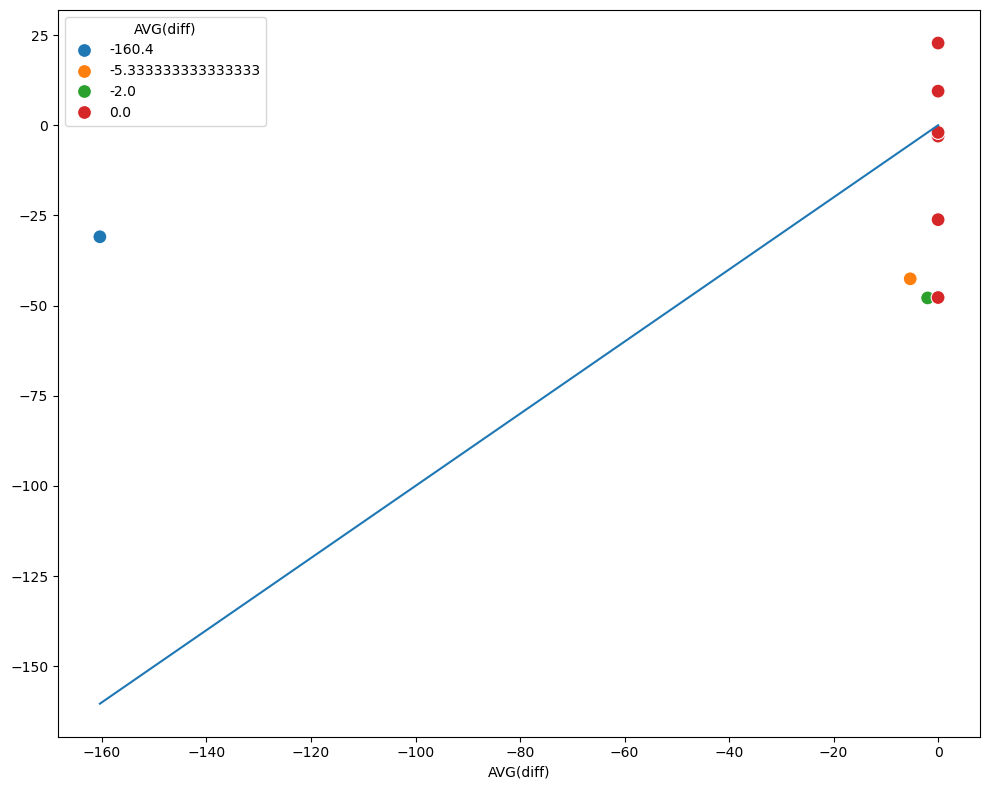

In [10]:
draw_plot(y_test, logreg_pred)

In [11]:
tree = DecisionTreeRegressor(random_state=21, max_depth=1)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)

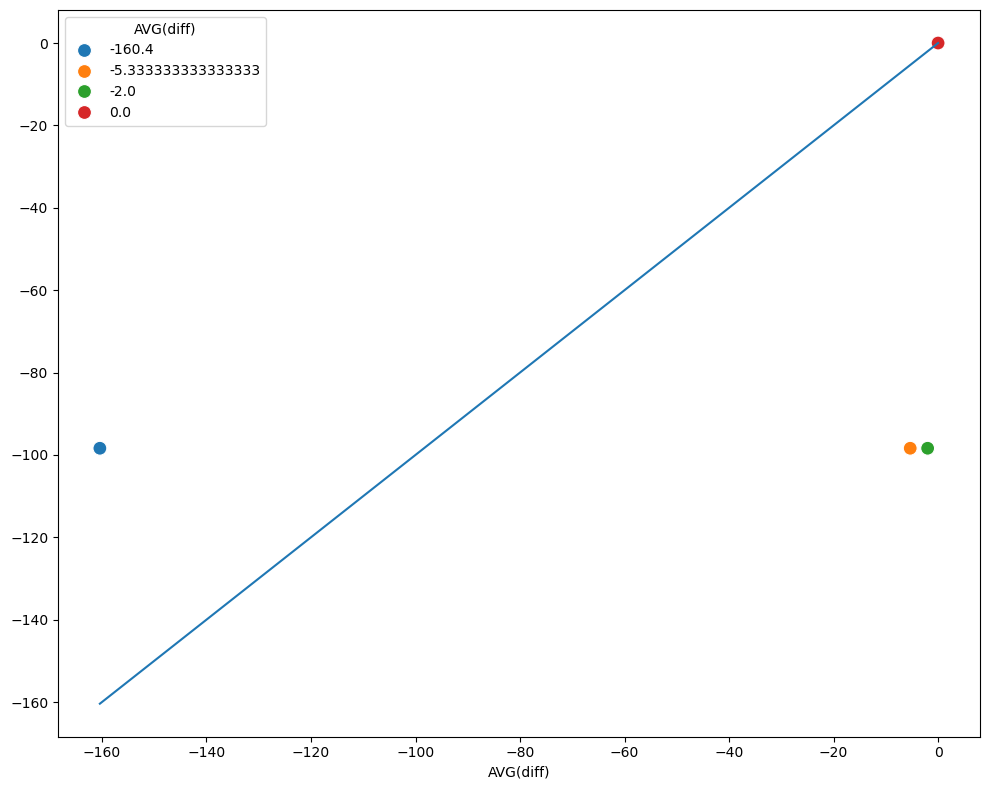

In [12]:
draw_plot(y_test, tree_pred)

In [13]:
forest = RandomForestRegressor(random_state=21, max_depth=10, n_estimators=100)
forest.fit(X_train, y_train)
forest_pred = forest.predict(X_test)

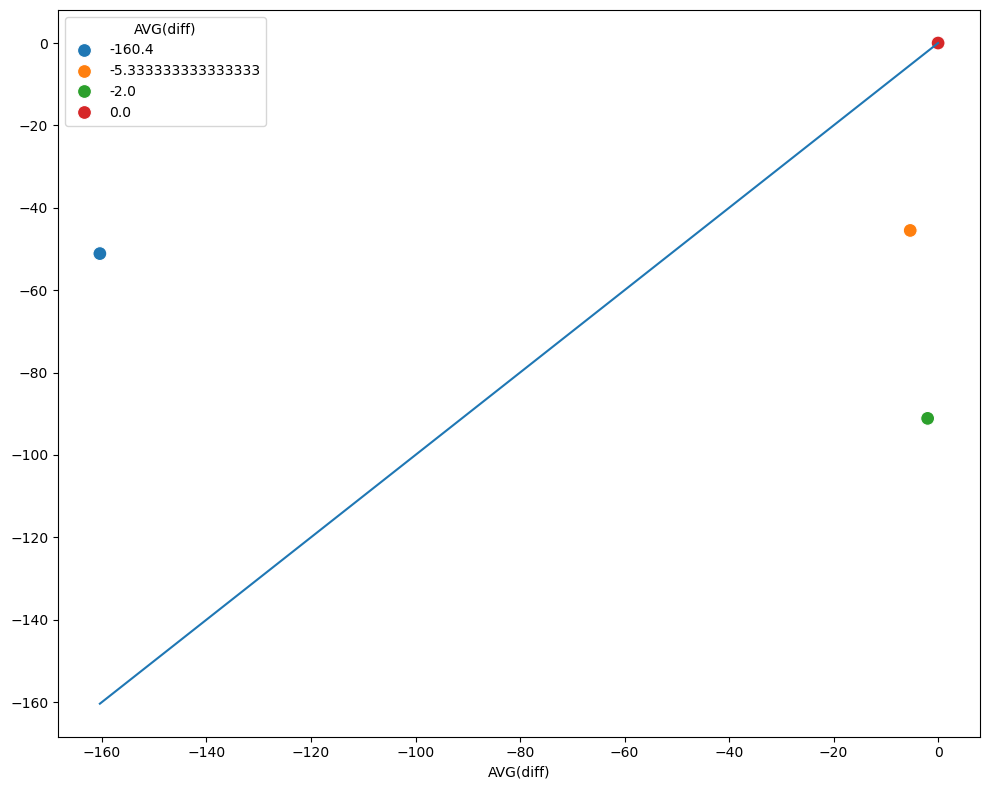

In [14]:
draw_plot(y_test, forest_pred)

## How would plot look like in the ideal case? 45 degree diagonal line.